# 第六章：指標網路 (Pointer Networks) - PyTorch 實作

## 論文：Pointer Networks
**作者**：Oriol Vinyals, Meire Fortunato, Navdeep Jaitly (2015)

本 notebook 實作指標網路，使用注意力機制來「指向」輸入元素，解決組合最佳化問題。

In [1]:
# 跨平台中文字型設定（支援 Colab、VSCode、Antigravity 等本地環境）
import subprocess
import os
import shutil
import platform

system = platform.system()

# 必須在 import matplotlib 之前清除快取
cache_dir = os.path.expanduser('~/.matplotlib')
if os.path.exists(cache_dir):
    for f in os.listdir(cache_dir):
        if f.startswith('fontlist'):
            try:
                os.remove(os.path.join(cache_dir, f))
            except:
                pass

cache_dir2 = os.path.expanduser('~/.cache/matplotlib')
if os.path.exists(cache_dir2):
    shutil.rmtree(cache_dir2, ignore_errors=True)

# Linux/Colab 環境安裝中文字型
if system == 'Linux' or 'COLAB_GPU' in os.environ or os.path.exists('/content'):
    try:
        result = subprocess.run(['fc-list', ':lang=zh'], capture_output=True, text=True)
        if 'Noto Sans CJK' not in result.stdout:
            print("正在安裝中文字型...")
            subprocess.run(['apt-get', 'update', '-qq'], capture_output=True)
            subprocess.run(['apt-get', 'install', '-qq', '-y', 'fonts-noto-cjk'], capture_output=True)
            print("中文字型安裝完成，請重新啟動 kernel")
    except:
        pass

print(f"✓ {system} 環境")

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt

# 重建字型快取並設定中文字型
from matplotlib.font_manager import fontManager
fontManager.__init__()

chinese_fonts = [
    'Heiti TC', 'PingFang TC', 'Noto Sans CJK TC',
    'Heiti SC', 'PingFang SC', 'Noto Sans CJK SC', 
    'Microsoft JhengHei', 'Microsoft YaHei',
    'SimHei', 'WenQuanYi Micro Hei', 'Arial Unicode MS',
]

available_fonts = set(f.name for f in fontManager.ttflist)
selected_font = None
for font in chinese_fonts:
    if font in available_fonts:
        selected_font = font
        break

if selected_font:
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = [selected_font] + chinese_fonts
    plt.rcParams['axes.unicode_minus'] = False
    print(f"✓ 使用中文字型: {selected_font}")
else:
    plt.rcParams['font.sans-serif'] = chinese_fonts
    plt.rcParams['axes.unicode_minus'] = False
    print("⚠ 使用預設字型列表")

from scipy.spatial import ConvexHull
import warnings
warnings.filterwarnings('ignore')

# 執行跨平台字型設定
setup_chinese_font()

# 跨平台中文字型優先順序
chinese_fonts = [
    'Noto Sans CJK TC',      # Linux/Colab/Mac(安裝後) 繁體
    'Noto Sans CJK SC',      # Linux/Colab/Mac(安裝後) 簡體
    'Heiti TC',              # Mac 內建 繁體
    'Heiti SC',              # Mac 內建 簡體
    'PingFang TC',           # Mac 內建 繁體
    'PingFang SC',           # Mac 內建 簡體
    'Microsoft JhengHei',    # Windows 微軟正黑體 繁體
    'Microsoft YaHei',       # Windows 微軟雅黑 簡體
    'SimHei',                # Windows 黑體
    'WenQuanYi Micro Hei',   # Linux 文泉驛微米黑
    'Droid Sans Fallback',   # Android/舊版 Linux
    'Arial Unicode MS',      # 跨平台 Unicode 字型
    'DejaVu Sans',           # 後備字型
]

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = chinese_fonts
plt.rcParams['axes.unicode_minus'] = False

# 驗證可用字型
from matplotlib.font_manager import FontManager
fm = FontManager()
available_fonts = set(f.name for f in fm.ttflist)
for font in chinese_fonts:
    if font in available_fonts:
        print(f"✓ 使用中文字型: {font}")
        break

# 設定隨機種子
torch.manual_seed(42)
np.random.seed(42)

# 設定裝置
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch 版本: {torch.__version__}")
print(f"使用裝置: {device}")

✓ Darwin 環境


Matplotlib is building the font cache; this may take a moment.


✓ 使用中文字型: Heiti TC
PyTorch 版本: 2.9.1
使用裝置: cpu


## 1. 指標注意力機制

指標網路的核心創新：使用注意力分布直接作為輸出，而不是計算加權上下文向量。

$$u_i^t = v^T \tanh(W_1 h_i + W_2 s_t)$$

$$p(C_t = i) = \text{softmax}(u^t)_i$$

In [3]:
class PointerAttention(nn.Module):
    """
    指標注意力機制
    
    與傳統注意力不同，這裡的注意力分布直接作為輸出（指向輸入的機率）
    """
    def __init__(self, hidden_dim):
        super().__init__()
        self.W1 = nn.Linear(hidden_dim, hidden_dim, bias=False)  # 編碼器狀態投影
        self.W2 = nn.Linear(hidden_dim, hidden_dim, bias=False)  # 解碼器狀態投影
        self.v = nn.Linear(hidden_dim, 1, bias=False)            # 分數計算
        
    def forward(self, encoder_outputs, decoder_state, mask=None):
        """
        參數:
            encoder_outputs: (batch, src_len, hidden_dim) - 編碼器所有隱藏狀態
            decoder_state: (batch, hidden_dim) - 解碼器當前隱藏狀態
            mask: (batch, src_len) - 可選的遮罩，0 表示被遮罩
            
        回傳:
            probs: (batch, src_len) - 指向每個輸入位置的機率
            scores: (batch, src_len) - 原始注意力分數（用於視覺化）
        """
        batch_size, src_len, hidden_dim = encoder_outputs.size()
        
        # 擴展 decoder_state: (batch, hidden_dim) -> (batch, 1, hidden_dim)
        decoder_state = decoder_state.unsqueeze(1)
        
        # 計算注意力分數
        # encoder_proj: (batch, src_len, hidden_dim)
        # decoder_proj: (batch, 1, hidden_dim)
        encoder_proj = self.W1(encoder_outputs)
        decoder_proj = self.W2(decoder_state)
        
        # 結合並計算分數: (batch, src_len, 1) -> (batch, src_len)
        scores = self.v(torch.tanh(encoder_proj + decoder_proj)).squeeze(-1)
        
        # 應用遮罩（如果有）
        if mask is not None:
            scores = scores.masked_fill(mask == 0, float('-inf'))
        
        # Softmax 得到機率分布
        probs = F.softmax(scores, dim=-1)
        
        return probs, scores


# 測試注意力機制
print("=" * 50)
print("測試指標注意力機制")
print("=" * 50)

hidden_dim = 64
batch_size = 2
src_len = 5

attention = PointerAttention(hidden_dim)
encoder_outputs = torch.randn(batch_size, src_len, hidden_dim)
decoder_state = torch.randn(batch_size, hidden_dim)

probs, scores = attention(encoder_outputs, decoder_state)

print(f"編碼器輸出形狀: {encoder_outputs.shape}")
print(f"解碼器狀態形狀: {decoder_state.shape}")
print(f"注意力機率形狀: {probs.shape}")
print(f"機率總和: {probs.sum(dim=-1)}")
print(f"\n第一個樣本的指標分布: {probs[0].detach().numpy().round(3)}")

測試指標注意力機制
編碼器輸出形狀: torch.Size([2, 5, 64])
解碼器狀態形狀: torch.Size([2, 64])
注意力機率形狀: torch.Size([2, 5])
機率總和: tensor([1., 1.], grad_fn=<SumBackward1>)

第一個樣本的指標分布: [0.309 0.14  0.147 0.236 0.167]


## 2. 編碼器

使用 LSTM 編碼輸入序列，產生每個位置的隱藏狀態。

In [4]:
class Encoder(nn.Module):
    """
    LSTM 編碼器
    
    將輸入序列編碼為隱藏狀態序列
    """
    def __init__(self, input_dim, hidden_dim, num_layers=1, bidirectional=False):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.bidirectional = bidirectional
        
        # 輸入嵌入層
        self.embedding = nn.Linear(input_dim, hidden_dim)
        
        # LSTM
        self.lstm = nn.LSTM(
            input_size=hidden_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=bidirectional
        )
        
        # 如果是雙向，需要投影回原始維度
        if bidirectional:
            self.proj = nn.Linear(hidden_dim * 2, hidden_dim)
        
    def forward(self, x):
        """
        參數:
            x: (batch, seq_len, input_dim) - 輸入序列
            
        回傳:
            outputs: (batch, seq_len, hidden_dim) - 所有隱藏狀態
            (h_n, c_n): 最終隱藏狀態和細胞狀態
        """
        # 嵌入
        embedded = self.embedding(x)  # (batch, seq_len, hidden_dim)
        
        # LSTM 編碼
        outputs, (h_n, c_n) = self.lstm(embedded)
        
        # 如果是雙向，合併並投影
        if self.bidirectional:
            outputs = self.proj(outputs)
            # 合併雙向的最終狀態
            h_n = h_n.view(self.num_layers, 2, -1, self.hidden_dim)
            h_n = h_n[:, 0, :, :] + h_n[:, 1, :, :]  # 相加
            c_n = c_n.view(self.num_layers, 2, -1, self.hidden_dim)
            c_n = c_n[:, 0, :, :] + c_n[:, 1, :, :]
        
        return outputs, (h_n, c_n)


# 測試編碼器
print("\n" + "=" * 50)
print("測試編碼器")
print("=" * 50)

input_dim = 2  # 2D 點座標
hidden_dim = 64
batch_size = 3
seq_len = 6

encoder = Encoder(input_dim, hidden_dim)
x = torch.randn(batch_size, seq_len, input_dim)

outputs, (h_n, c_n) = encoder(x)

print(f"輸入形狀: {x.shape}")
print(f"編碼器輸出形狀: {outputs.shape}")
print(f"最終隱藏狀態形狀: {h_n.shape}")
print(f"最終細胞狀態形狀: {c_n.shape}")


測試編碼器
輸入形狀: torch.Size([3, 6, 2])
編碼器輸出形狀: torch.Size([3, 6, 64])
最終隱藏狀態形狀: torch.Size([1, 3, 64])
最終細胞狀態形狀: torch.Size([1, 3, 64])


## 3. 解碼器

解碼器在每一步使用指標注意力來選擇一個輸入位置。

In [5]:
class Decoder(nn.Module):
    """
    帶指標注意力的 LSTM 解碼器
    """
    def __init__(self, input_dim, hidden_dim):
        super().__init__()
        self.hidden_dim = hidden_dim
        
        # 輸入嵌入
        self.embedding = nn.Linear(input_dim, hidden_dim)
        
        # LSTM 細胞
        self.lstm_cell = nn.LSTMCell(hidden_dim, hidden_dim)
        
        # 指標注意力
        self.attention = PointerAttention(hidden_dim)
        
    def forward(self, x, hidden, encoder_outputs, mask=None):
        """
        單步解碼
        
        參數:
            x: (batch, input_dim) - 上一步被指向的輸入
            hidden: (h, c) - 隱藏狀態，各為 (batch, hidden_dim)
            encoder_outputs: (batch, src_len, hidden_dim) - 編碼器輸出
            mask: (batch, src_len) - 可選遮罩
            
        回傳:
            probs: (batch, src_len) - 指標機率分布
            hidden: 更新後的隱藏狀態
        """
        # 嵌入輸入
        embedded = self.embedding(x)  # (batch, hidden_dim)
        
        # LSTM 更新
        h, c = hidden
        h, c = self.lstm_cell(embedded, (h, c))
        
        # 計算指標分布
        probs, scores = self.attention(encoder_outputs, h, mask)
        
        return probs, (h, c), scores


# 測試解碼器
print("\n" + "=" * 50)
print("測試解碼器")
print("=" * 50)

decoder = Decoder(input_dim, hidden_dim)

# 使用編碼器的最終狀態初始化
h = h_n.squeeze(0)  # (batch, hidden_dim)
c = c_n.squeeze(0)

# 第一步輸入（可以是起始標記或平均輸入）
decoder_input = x.mean(dim=1)  # (batch, input_dim)

probs, (h, c), scores = decoder(decoder_input, (h, c), outputs)

print(f"解碼器輸入形狀: {decoder_input.shape}")
print(f"指標機率形狀: {probs.shape}")
print(f"更新後隱藏狀態形狀: {h.shape}")
print(f"\n第一個樣本的指標分布: {probs[0].detach().numpy().round(3)}")


測試解碼器
解碼器輸入形狀: torch.Size([3, 2])
指標機率形狀: torch.Size([3, 6])
更新後隱藏狀態形狀: torch.Size([3, 64])

第一個樣本的指標分布: [0.171 0.168 0.168 0.163 0.166 0.164]


## 4. 完整指標網路

In [6]:
class PointerNetwork(nn.Module):
    """
    完整的指標網路
    
    由編碼器和解碼器組成，用於解決組合最佳化問題
    """
    def __init__(self, input_dim, hidden_dim, use_mask=True):
        super().__init__()
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.use_mask = use_mask
        
        self.encoder = Encoder(input_dim, hidden_dim)
        self.decoder = Decoder(input_dim, hidden_dim)
        
    def forward(self, inputs, targets=None, teacher_forcing_ratio=0.5):
        """
        前向傳播
        
        參數:
            inputs: (batch, seq_len, input_dim) - 輸入序列
            targets: (batch, output_len) - 目標索引序列（訓練時）
            teacher_forcing_ratio: teacher forcing 的機率
            
        回傳:
            all_probs: (batch, output_len, seq_len) - 每步的指標分布
            all_indices: (batch, output_len) - 預測的索引序列
        """
        batch_size = inputs.size(0)
        seq_len = inputs.size(1)
        
        # 確定輸出長度
        if targets is not None:
            output_len = targets.size(1)
        else:
            output_len = seq_len
        
        # 編碼
        encoder_outputs, (h_n, c_n) = self.encoder(inputs)
        
        # 初始化解碼器
        h = h_n.squeeze(0)  # (batch, hidden_dim)
        c = c_n.squeeze(0)
        
        # 初始化遮罩（追蹤已選擇的位置）
        if self.use_mask:
            mask = torch.ones(batch_size, seq_len, device=inputs.device)
        else:
            mask = None
        
        # 起始輸入
        decoder_input = inputs.mean(dim=1)  # (batch, input_dim)
        
        all_probs = []
        all_indices = []
        
        for t in range(output_len):
            # 解碼一步
            probs, (h, c), scores = self.decoder(
                decoder_input, (h, c), encoder_outputs, mask
            )
            all_probs.append(probs)
            
            # 選擇下一個位置
            if self.training and targets is not None:
                # Teacher forcing
                use_teacher_forcing = np.random.random() < teacher_forcing_ratio
                if use_teacher_forcing:
                    indices = targets[:, t]
                else:
                    indices = probs.argmax(dim=-1)
            else:
                # 推理時使用貪婪選擇
                indices = probs.argmax(dim=-1)
            
            all_indices.append(indices)
            
            # 更新遮罩（標記已選擇的位置）
            if self.use_mask and mask is not None:
                mask = mask.scatter(1, indices.unsqueeze(1), 0)
            
            # 獲取被指向的輸入作為下一步輸入
            decoder_input = inputs[
                torch.arange(batch_size, device=inputs.device),
                indices
            ]
        
        all_probs = torch.stack(all_probs, dim=1)  # (batch, output_len, seq_len)
        all_indices = torch.stack(all_indices, dim=1)  # (batch, output_len)
        
        return all_probs, all_indices
    
    def greedy_decode(self, inputs):
        """貪婪解碼（推理時使用）"""
        self.eval()
        with torch.no_grad():
            _, indices = self.forward(inputs)
        return indices


# 測試完整網路
print("\n" + "=" * 50)
print("測試完整指標網路")
print("=" * 50)

model = PointerNetwork(input_dim=2, hidden_dim=64)

# 測試輸入
batch_size = 4
seq_len = 8
inputs = torch.randn(batch_size, seq_len, 2)

# 前向傳播
model.eval()
probs, indices = model(inputs)

print(f"輸入形狀: {inputs.shape}")
print(f"輸出機率形狀: {probs.shape}")
print(f"預測索引形狀: {indices.shape}")
print(f"\n預測的索引序列:")
for i in range(batch_size):
    print(f"  樣本 {i}: {indices[i].tolist()}")


測試完整指標網路
輸入形狀: torch.Size([4, 8, 2])
輸出機率形狀: torch.Size([4, 8, 8])
預測索引形狀: torch.Size([4, 8])

預測的索引序列:
  樣本 0: [5, 0, 6, 4, 7, 3, 1, 2]
  樣本 1: [7, 6, 4, 5, 0, 1, 2, 3]
  樣本 2: [2, 1, 7, 5, 6, 3, 4, 0]
  樣本 3: [3, 2, 4, 5, 7, 0, 1, 6]


## 5. 凸包資料集

In [7]:
class ConvexHullDataset(Dataset):
    """
    凸包資料集
    
    生成隨機 2D 點並計算其凸包
    """
    def __init__(self, num_samples, num_points, seed=None):
        super().__init__()
        self.num_points = num_points
        self.data = []
        
        if seed is not None:
            np.random.seed(seed)
        
        attempts = 0
        while len(self.data) < num_samples and attempts < num_samples * 10:
            attempts += 1
            
            # 生成隨機點
            points = np.random.rand(num_points, 2).astype(np.float32)
            
            try:
                # 計算凸包
                hull = ConvexHull(points)
                hull_indices = hull.vertices.tolist()
                
                # 確保凸包至少有 3 個頂點
                if len(hull_indices) >= 3:
                    self.data.append({
                        'points': points,
                        'hull_indices': hull_indices,
                        'hull_len': len(hull_indices)
                    })
            except:
                continue
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        item = self.data[idx]
        points = torch.tensor(item['points'])
        
        # 將凸包索引填充到固定長度
        hull_indices = item['hull_indices'].copy()
        hull_len = len(hull_indices)
        
        # 填充 -1 表示無效位置
        while len(hull_indices) < self.num_points:
            hull_indices.append(-1)
        
        targets = torch.tensor(hull_indices)
        
        return points, targets, hull_len


# 建立資料集
print("\n" + "=" * 50)
print("建立凸包資料集")
print("=" * 50)

train_dataset = ConvexHullDataset(num_samples=5000, num_points=10, seed=42)
test_dataset = ConvexHullDataset(num_samples=500, num_points=10, seed=123)

print(f"訓練集大小: {len(train_dataset)}")
print(f"測試集大小: {len(test_dataset)}")

# 檢視範例
points, targets, hull_len = train_dataset[0]
print(f"\n範例:")
print(f"  點的形狀: {points.shape}")
print(f"  目標形狀: {targets.shape}")
print(f"  凸包長度: {hull_len}")
print(f"  凸包索引: {targets[:hull_len].tolist()}")


建立凸包資料集
訓練集大小: 5000
測試集大小: 500

範例:
  點的形狀: torch.Size([10, 2])
  目標形狀: torch.Size([10])
  凸包長度: 5
  凸包索引: [5, 2, 6, 1, 0]


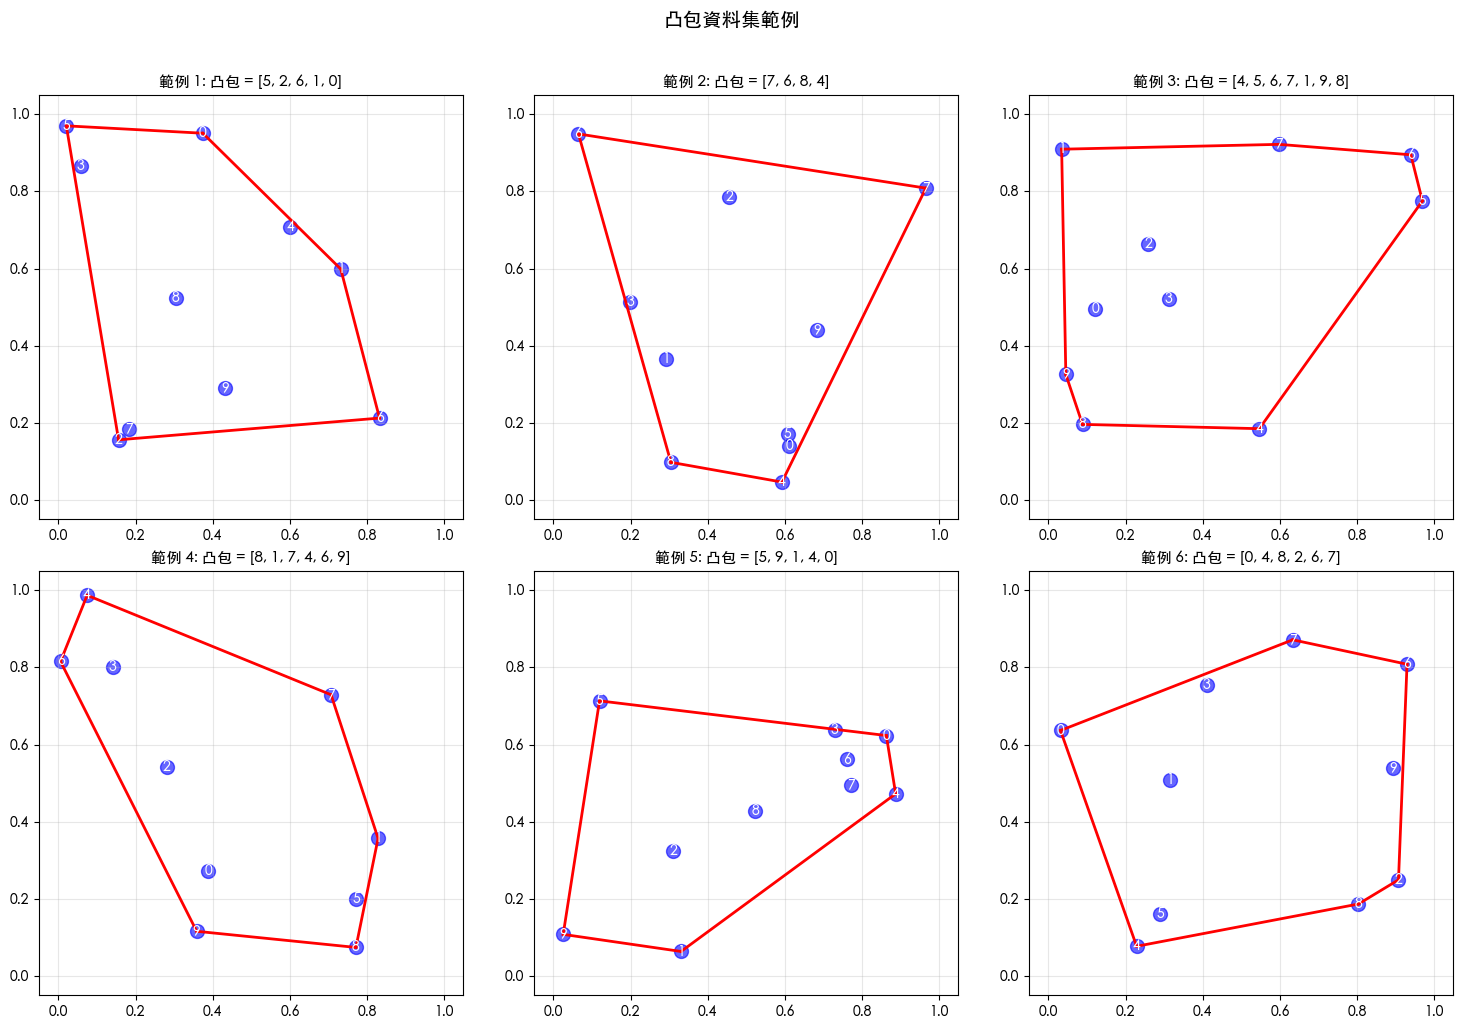

In [8]:
# 視覺化凸包資料
def visualize_convex_hull(points, hull_indices, title="凸包範例"):
    """視覺化點集和凸包"""
    plt.figure(figsize=(8, 8))
    
    # 繪製所有點
    plt.scatter(points[:, 0], points[:, 1], s=150, c='blue', alpha=0.6, zorder=2)
    
    # 標記點的索引
    for i, (x, y) in enumerate(points):
        plt.annotate(str(i), (x, y), fontsize=12, ha='center', va='center',
                    fontweight='bold', color='white')
    
    # 繪製凸包邊
    hull_indices = [i for i in hull_indices if i >= 0]  # 過濾填充值
    for i in range(len(hull_indices)):
        start = hull_indices[i]
        end = hull_indices[(i + 1) % len(hull_indices)]
        plt.plot([points[start, 0], points[end, 0]],
                [points[start, 1], points[end, 1]],
                'r-', linewidth=2, zorder=1)
    
    # 突顯凸包頂點
    hull_points = points[hull_indices]
    plt.scatter(hull_points[:, 0], hull_points[:, 1],
               s=250, c='red', alpha=0.3, zorder=3)
    
    plt.title(title, fontsize=14)
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.grid(True, alpha=0.3)
    plt.axis('equal')
    plt.tight_layout()
    plt.show()


# 視覺化幾個範例
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for idx, ax in enumerate(axes.flatten()):
    points, targets, hull_len = train_dataset[idx]
    points = points.numpy()
    hull_indices = targets[:hull_len].tolist()
    
    # 繪製點
    ax.scatter(points[:, 0], points[:, 1], s=100, c='blue', alpha=0.6)
    
    # 標記索引
    for i, (x, y) in enumerate(points):
        ax.annotate(str(i), (x, y), fontsize=10, ha='center', va='center',
                   fontweight='bold', color='white')
    
    # 繪製凸包
    for i in range(len(hull_indices)):
        start = hull_indices[i]
        end = hull_indices[(i + 1) % len(hull_indices)]
        ax.plot([points[start, 0], points[end, 0]],
               [points[start, 1], points[end, 1]],
               'r-', linewidth=2)
    
    ax.set_title(f'範例 {idx+1}: 凸包 = {hull_indices}', fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.set_aspect('equal')

plt.suptitle('凸包資料集範例', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 6. 訓練指標網路

In [9]:
def collate_fn(batch):
    """自訂整理函數處理可變長度"""
    points_batch = torch.stack([item[0] for item in batch])
    targets_batch = torch.stack([item[1] for item in batch])
    lens = [item[2] for item in batch]
    return points_batch, targets_batch, lens


def compute_loss(probs, targets, target_lens):
    """
    計算交叉熵損失（只對有效位置）
    
    參數:
        probs: (batch, output_len, seq_len) - 預測機率
        targets: (batch, output_len) - 目標索引
        target_lens: 每個樣本的有效長度列表
    """
    batch_size = probs.size(0)
    total_loss = 0
    total_count = 0
    
    for i in range(batch_size):
        valid_len = target_lens[i]
        if valid_len > 0:
            # 只計算有效位置的損失
            loss = F.cross_entropy(
                probs[i, :valid_len],
                targets[i, :valid_len],
                reduction='sum'
            )
            total_loss += loss
            total_count += valid_len
    
    return total_loss / max(total_count, 1)


def compute_accuracy(probs, targets, target_lens):
    """
    計算預測準確率
    """
    batch_size = probs.size(0)
    predictions = probs.argmax(dim=-1)
    
    total_correct = 0
    total_count = 0
    exact_match = 0
    
    for i in range(batch_size):
        valid_len = target_lens[i]
        if valid_len > 0:
            pred = predictions[i, :valid_len]
            target = targets[i, :valid_len]
            
            correct = (pred == target).sum().item()
            total_correct += correct
            total_count += valid_len
            
            # 完全匹配
            if correct == valid_len:
                exact_match += 1
    
    token_acc = total_correct / max(total_count, 1)
    exact_acc = exact_match / batch_size
    
    return token_acc, exact_acc


# 建立資料載入器
batch_size = 64
train_loader = DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn
)
test_loader = DataLoader(
    test_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn
)

print(f"訓練批次數: {len(train_loader)}")
print(f"測試批次數: {len(test_loader)}")

訓練批次數: 79
測試批次數: 8


In [10]:
def train_epoch(model, loader, optimizer, device, teacher_forcing_ratio=0.5):
    """訓練一個 epoch"""
    model.train()
    total_loss = 0
    total_token_acc = 0
    total_exact_acc = 0
    num_batches = 0
    
    for points, targets, target_lens in loader:
        points = points.to(device)
        targets = targets.to(device)
        
        optimizer.zero_grad()
        
        # 前向傳播
        probs, indices = model(points, targets, teacher_forcing_ratio)
        
        # 計算損失
        loss = compute_loss(probs, targets, target_lens)
        
        # 反向傳播
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        # 統計
        total_loss += loss.item()
        token_acc, exact_acc = compute_accuracy(probs, targets, target_lens)
        total_token_acc += token_acc
        total_exact_acc += exact_acc
        num_batches += 1
    
    return {
        'loss': total_loss / num_batches,
        'token_acc': total_token_acc / num_batches,
        'exact_acc': total_exact_acc / num_batches
    }


def evaluate(model, loader, device):
    """評估模型"""
    model.eval()
    total_loss = 0
    total_token_acc = 0
    total_exact_acc = 0
    num_batches = 0
    
    with torch.no_grad():
        for points, targets, target_lens in loader:
            points = points.to(device)
            targets = targets.to(device)
            
            probs, indices = model(points)
            
            loss = compute_loss(probs, targets, target_lens)
            total_loss += loss.item()
            
            token_acc, exact_acc = compute_accuracy(probs, targets, target_lens)
            total_token_acc += token_acc
            total_exact_acc += exact_acc
            num_batches += 1
    
    return {
        'loss': total_loss / num_batches,
        'token_acc': total_token_acc / num_batches,
        'exact_acc': total_exact_acc / num_batches
    }

In [11]:
# 訓練模型
print("\n" + "=" * 50)
print("訓練指標網路")
print("=" * 50)

# 模型設定
input_dim = 2
hidden_dim = 128
model = PointerNetwork(input_dim, hidden_dim, use_mask=False).to(device)

# 最佳化器
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

# 訓練記錄
history = {
    'train_loss': [], 'train_token_acc': [], 'train_exact_acc': [],
    'test_loss': [], 'test_token_acc': [], 'test_exact_acc': []
}

num_epochs = 30
best_test_acc = 0

print(f"\n模型參數數量: {sum(p.numel() for p in model.parameters()):,}")
print(f"訓練 {num_epochs} 個 epochs...\n")

for epoch in range(1, num_epochs + 1):
    # Teacher forcing 比率逐漸降低
    tf_ratio = max(0.2, 1.0 - epoch / num_epochs)
    
    # 訓練
    train_metrics = train_epoch(model, train_loader, optimizer, device, tf_ratio)
    
    # 評估
    test_metrics = evaluate(model, test_loader, device)
    
    # 更新學習率
    scheduler.step(test_metrics['loss'])
    
    # 記錄
    for key in ['loss', 'token_acc', 'exact_acc']:
        history[f'train_{key}'].append(train_metrics[key])
        history[f'test_{key}'].append(test_metrics[key])
    
    # 更新最佳模型
    if test_metrics['exact_acc'] > best_test_acc:
        best_test_acc = test_metrics['exact_acc']
        best_model_state = model.state_dict().copy()
    
    # 列印進度
    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{num_epochs} | "
              f"Train Loss: {train_metrics['loss']:.4f}, "
              f"Token Acc: {train_metrics['token_acc']:.4f}, "
              f"Exact Acc: {train_metrics['exact_acc']:.4f} | "
              f"Test Loss: {test_metrics['loss']:.4f}, "
              f"Token Acc: {test_metrics['token_acc']:.4f}, "
              f"Exact Acc: {test_metrics['exact_acc']:.4f}")

print(f"\n訓練完成！最佳測試精確匹配率: {best_test_acc:.4f}")


訓練指標網路

模型參數數量: 297,856
訓練 30 個 epochs...

Epoch   1/30 | Train Loss: 2.1840, Token Acc: 0.2966, Exact Acc: 0.0006 | Test Loss: 2.2671, Token Acc: 0.1901, Exact Acc: 0.0337
Epoch   5/30 | Train Loss: 1.7581, Token Acc: 0.7429, Exact Acc: 0.1800 | Test Loss: 2.1334, Token Acc: 0.3342, Exact Acc: 0.2200
Epoch  10/30 | Train Loss: 1.7460, Token Acc: 0.7431, Exact Acc: 0.2385 | Test Loss: 2.1236, Token Acc: 0.3417, Exact Acc: 0.2326
Epoch  15/30 | Train Loss: 1.8018, Token Acc: 0.6800, Exact Acc: 0.2892 | Test Loss: 2.1148, Token Acc: 0.3456, Exact Acc: 0.2141
Epoch  20/30 | Train Loss: 1.7825, Token Acc: 0.6971, Exact Acc: 0.3467 | Test Loss: 2.1145, Token Acc: 0.3474, Exact Acc: 0.2574
Epoch  25/30 | Train Loss: 1.8533, Token Acc: 0.6225, Exact Acc: 0.3807 | Test Loss: 2.1044, Token Acc: 0.3593, Exact Acc: 0.2622
Epoch  30/30 | Train Loss: 1.8333, Token Acc: 0.6418, Exact Acc: 0.4090 | Test Loss: 2.1068, Token Acc: 0.3529, Exact Acc: 0.2330

訓練完成！最佳測試精確匹配率: 0.2656


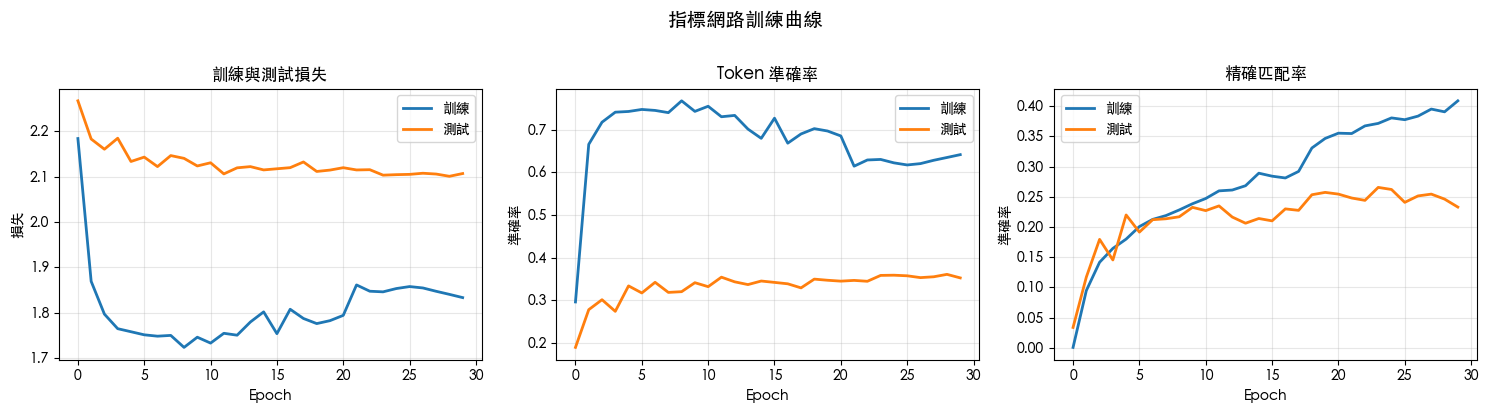

In [12]:
# 繪製訓練曲線
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 損失
ax = axes[0]
ax.plot(history['train_loss'], label='訓練', linewidth=2)
ax.plot(history['test_loss'], label='測試', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('損失')
ax.set_title('訓練與測試損失')
ax.legend()
ax.grid(True, alpha=0.3)

# Token 準確率
ax = axes[1]
ax.plot(history['train_token_acc'], label='訓練', linewidth=2)
ax.plot(history['test_token_acc'], label='測試', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('準確率')
ax.set_title('Token 準確率')
ax.legend()
ax.grid(True, alpha=0.3)

# 精確匹配率
ax = axes[2]
ax.plot(history['train_exact_acc'], label='訓練', linewidth=2)
ax.plot(history['test_exact_acc'], label='測試', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('準確率')
ax.set_title('精確匹配率')
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle('指標網路訓練曲線', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 7. 視覺化預測結果


預測結果視覺化


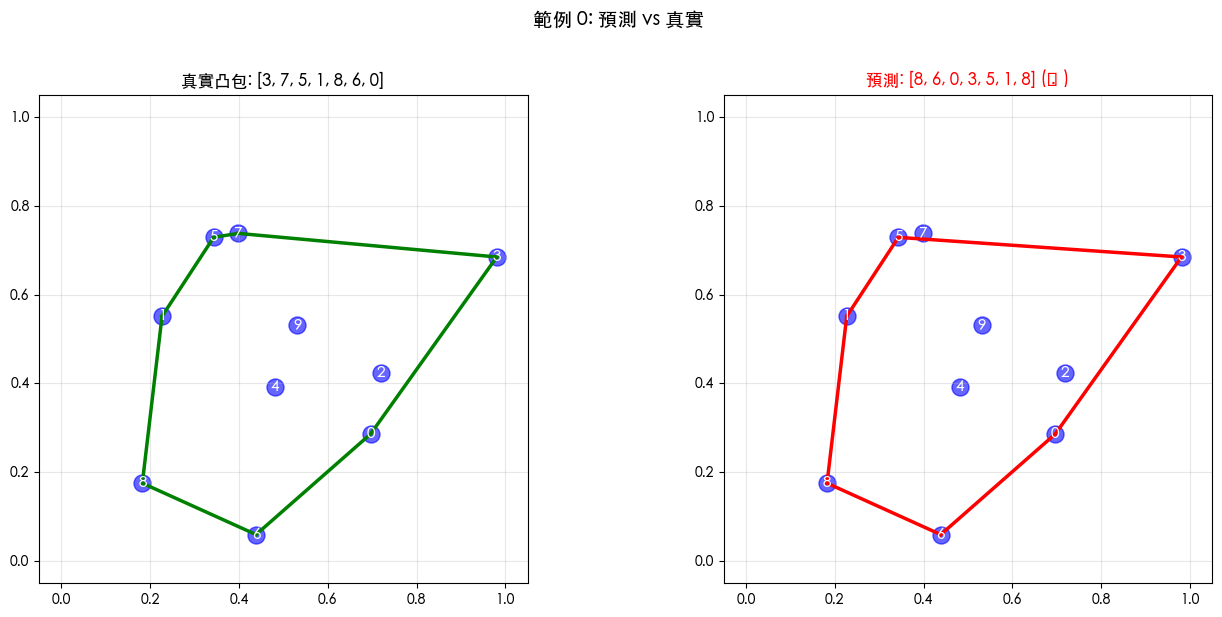

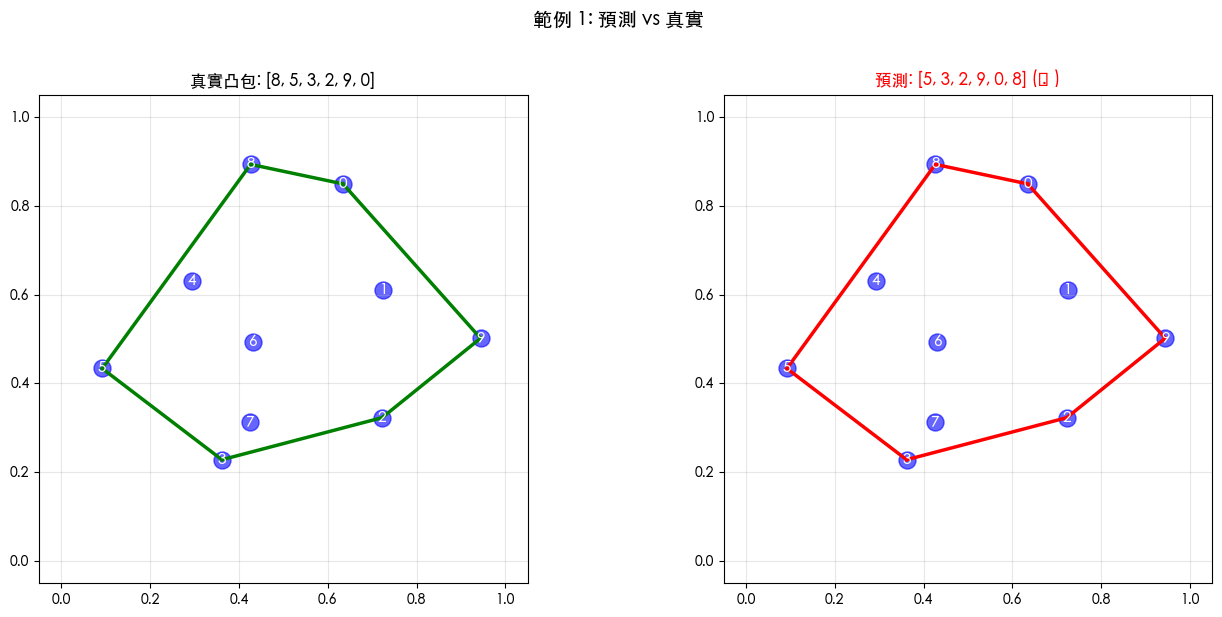

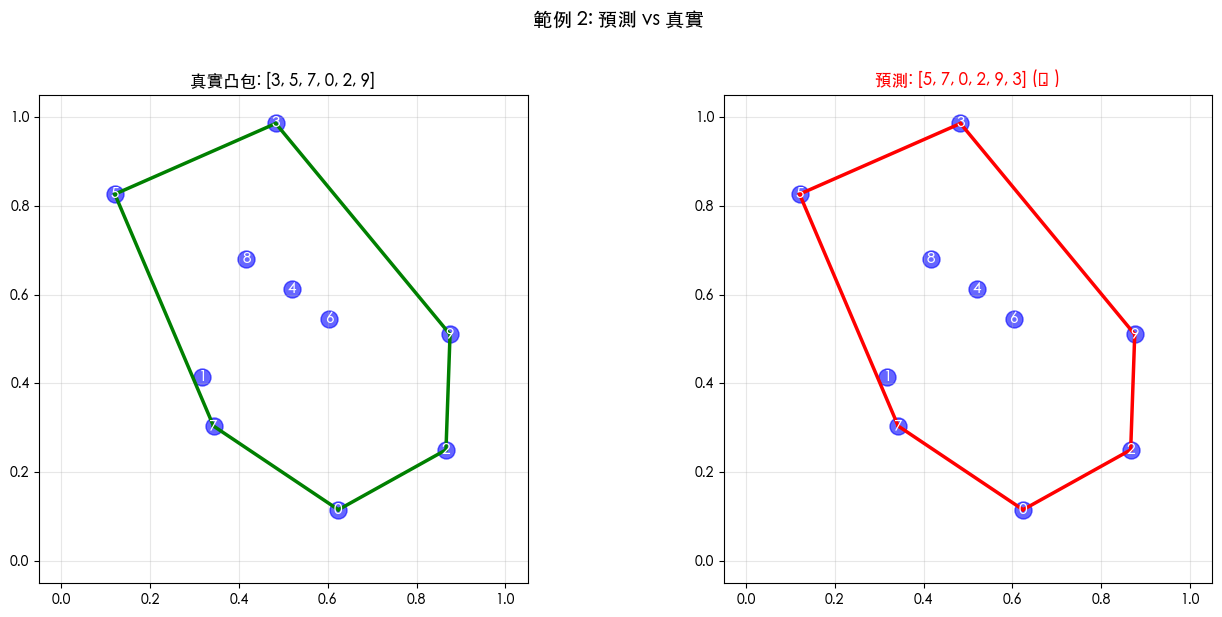

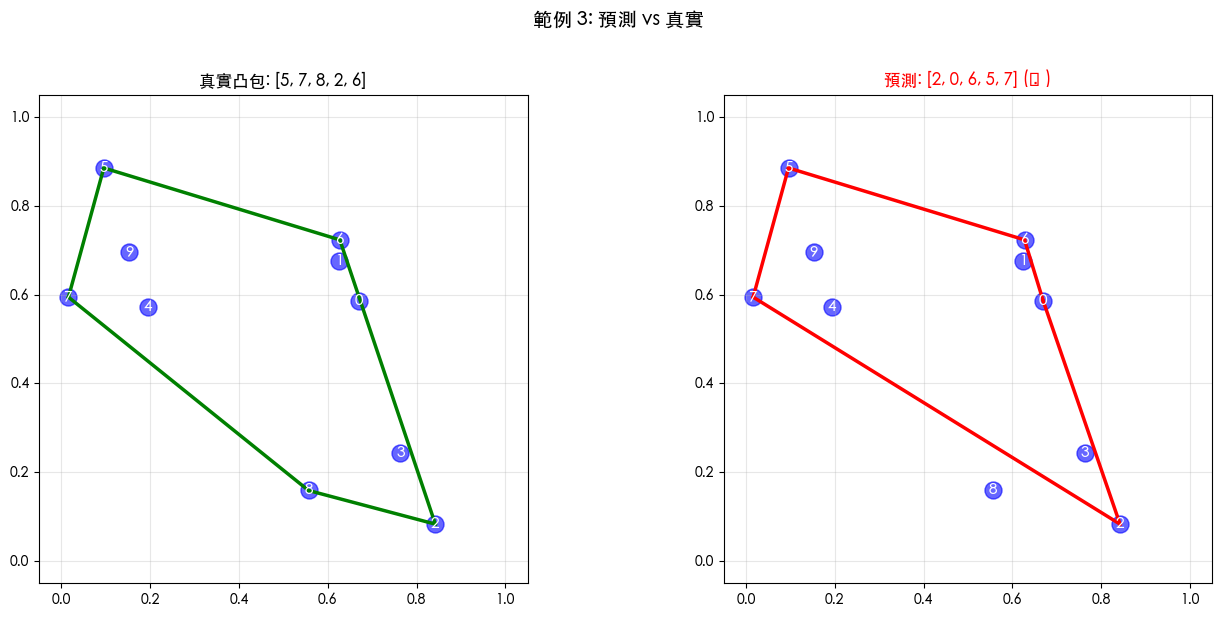

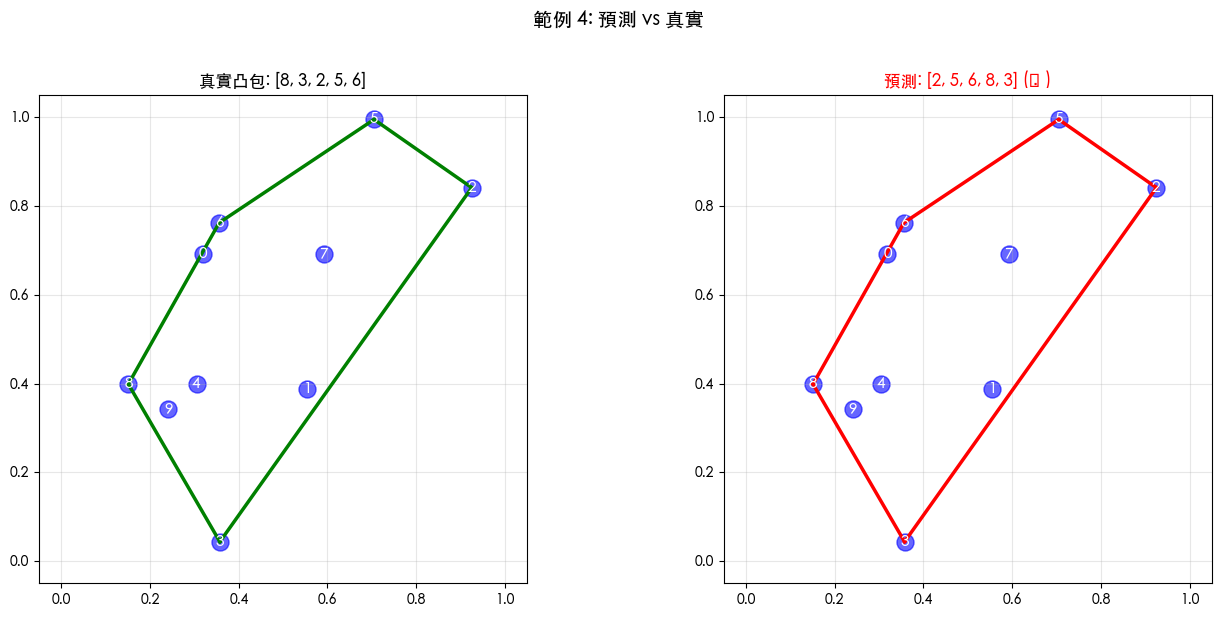

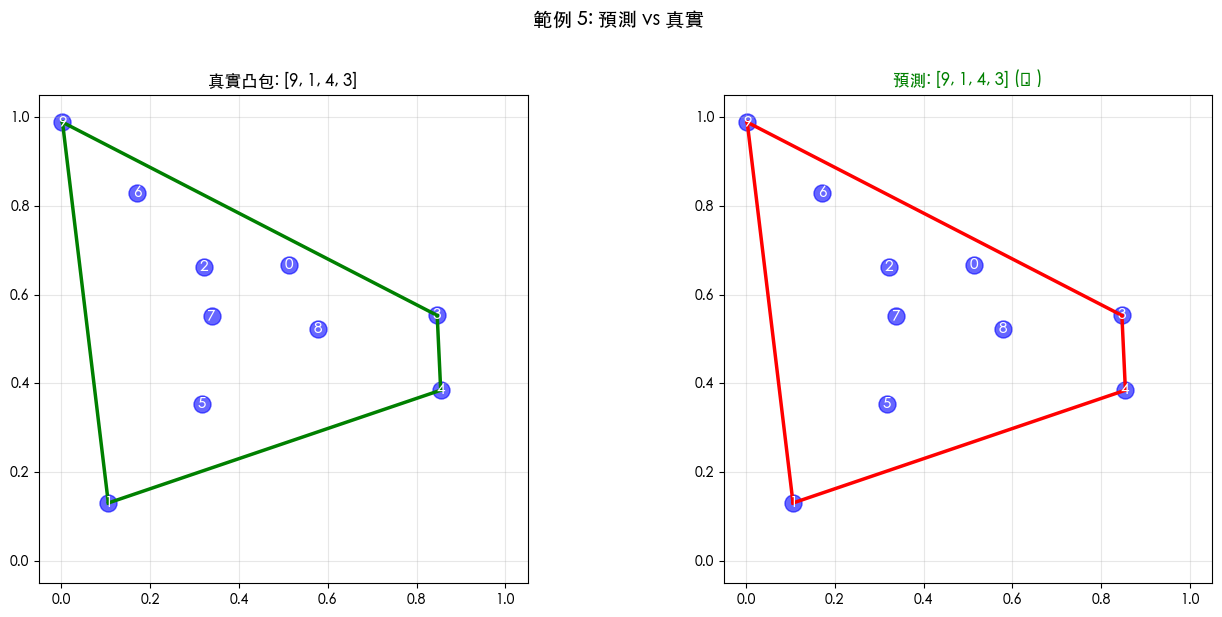


前 6 個測試樣本的精確匹配率: 1/6 = 16.67%


In [13]:
def visualize_prediction(model, dataset, idx, device):
    """視覺化模型的預測結果與真實凸包"""
    model.eval()
    
    points, targets, target_len = dataset[idx]
    points_tensor = points.unsqueeze(0).to(device)
    
    # 預測
    with torch.no_grad():
        probs, indices = model(points_tensor)
    
    predicted = indices[0].cpu().numpy()
    true_hull = targets[:target_len].numpy()
    points = points.numpy()
    
    # 繪圖
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # 真實凸包
    ax = axes[0]
    ax.scatter(points[:, 0], points[:, 1], s=150, c='blue', alpha=0.6)
    for i, (x, y) in enumerate(points):
        ax.annotate(str(i), (x, y), fontsize=11, ha='center', va='center',
                   fontweight='bold', color='white')
    
    for i in range(len(true_hull)):
        start = true_hull[i]
        end = true_hull[(i + 1) % len(true_hull)]
        ax.plot([points[start, 0], points[end, 0]],
               [points[start, 1], points[end, 1]],
               'g-', linewidth=2.5)
    
    ax.set_title(f'真實凸包: {true_hull.tolist()}', fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.set_aspect('equal')
    
    # 預測凸包
    ax = axes[1]
    ax.scatter(points[:, 0], points[:, 1], s=150, c='blue', alpha=0.6)
    for i, (x, y) in enumerate(points):
        ax.annotate(str(i), (x, y), fontsize=11, ha='center', va='center',
                   fontweight='bold', color='white')
    
    # 只繪製有效長度的預測
    pred_len = target_len  # 使用真實長度來比較
    for i in range(pred_len):
        start = predicted[i]
        end = predicted[(i + 1) % pred_len]
        ax.plot([points[start, 0], points[end, 0]],
               [points[start, 1], points[end, 1]],
               'r-', linewidth=2.5)
    
    # 檢查是否正確
    is_correct = np.array_equal(predicted[:pred_len], true_hull)
    color = 'green' if is_correct else 'red'
    
    ax.set_title(f'預測: {predicted[:pred_len].tolist()} ({"✓" if is_correct else "✗"})',
                fontsize=12, color=color)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.set_aspect('equal')
    
    plt.suptitle(f'範例 {idx}: 預測 vs 真實', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()
    
    return is_correct


# 載入最佳模型
model.load_state_dict(best_model_state)

# 視覺化幾個測試範例
print("\n" + "=" * 50)
print("預測結果視覺化")
print("=" * 50)

correct_count = 0
for i in range(6):
    is_correct = visualize_prediction(model, test_dataset, i, device)
    correct_count += is_correct

print(f"\n前 6 個測試樣本的精確匹配率: {correct_count}/6 = {correct_count/6:.2%}")

## 8. 注意力視覺化


注意力分布視覺化


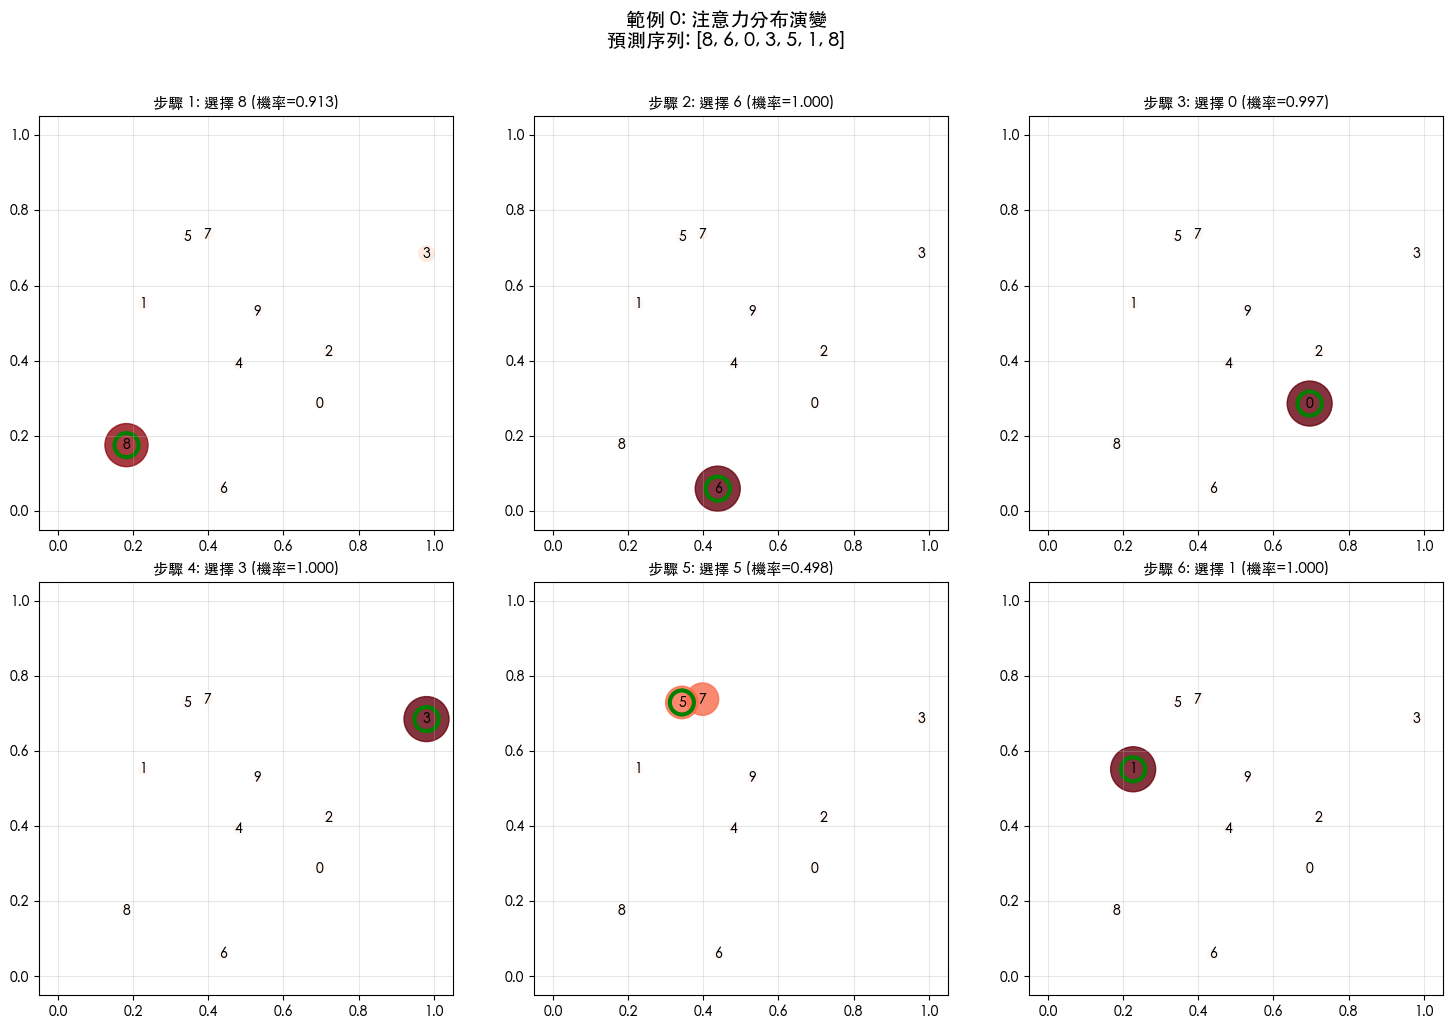

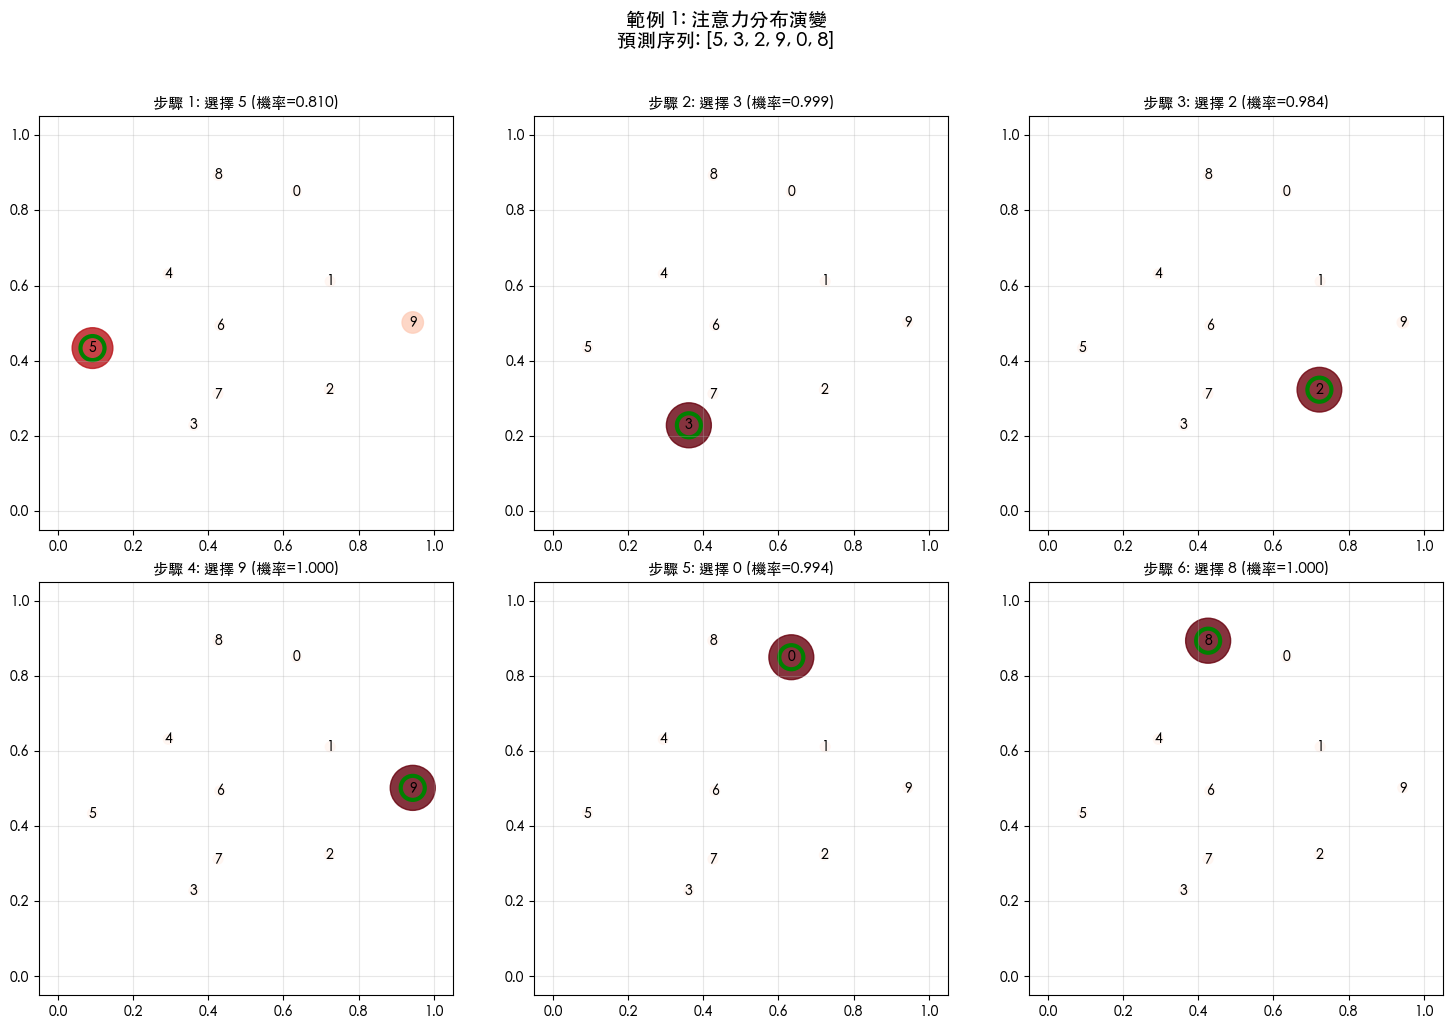

In [14]:
def visualize_attention_steps(model, dataset, idx, device):
    """視覺化每一步解碼的注意力分布"""
    model.eval()
    
    points, targets, target_len = dataset[idx]
    points_tensor = points.unsqueeze(0).to(device)
    
    # 獲取注意力分布
    with torch.no_grad():
        probs, indices = model(points_tensor)
    
    probs = probs[0].cpu().numpy()  # (output_len, seq_len)
    predicted = indices[0].cpu().numpy()
    points = points.numpy()
    
    # 繪製每一步的注意力
    num_steps = min(target_len, 6)  # 最多顯示 6 步
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    for step in range(num_steps):
        ax = axes[step]
        attention = probs[step]
        
        # 繪製點（大小和顏色根據注意力權重）
        scatter = ax.scatter(
            points[:, 0], points[:, 1],
            s=attention * 1000 + 50,
            c=attention, cmap='Reds',
            alpha=0.8, vmin=0, vmax=1
        )
        
        # 標記索引
        for i, (x, y) in enumerate(points):
            ax.annotate(str(i), (x, y), fontsize=10, ha='center', va='center',
                       fontweight='bold')
        
        # 標記選中的點
        selected = predicted[step]
        ax.scatter([points[selected, 0]], [points[selected, 1]],
                  s=300, facecolors='none', edgecolors='green', linewidths=3)
        
        ax.set_title(f'步驟 {step+1}: 選擇 {selected} (機率={attention[selected]:.3f})',
                    fontsize=11)
        ax.grid(True, alpha=0.3)
        ax.set_xlim(-0.05, 1.05)
        ax.set_ylim(-0.05, 1.05)
        ax.set_aspect('equal')
    
    # 隱藏多餘的子圖
    for step in range(num_steps, 6):
        axes[step].axis('off')
    
    plt.suptitle(f'範例 {idx}: 注意力分布演變\n預測序列: {predicted[:target_len].tolist()}',
                fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()


# 視覺化注意力
print("\n" + "=" * 50)
print("注意力分布視覺化")
print("=" * 50)

visualize_attention_steps(model, test_dataset, 0, device)
visualize_attention_steps(model, test_dataset, 1, device)

## 9. 排序任務演示

指標網路也可以用於排序任務：給定一組數字，輸出它們排序後的索引。

In [15]:
class SortingDataset(Dataset):
    """排序任務資料集"""
    def __init__(self, num_samples, seq_len, seed=None):
        self.seq_len = seq_len
        self.data = []
        
        if seed is not None:
            np.random.seed(seed)
        
        for _ in range(num_samples):
            # 生成隨機值
            values = np.random.rand(seq_len).astype(np.float32)
            # 排序索引
            sorted_indices = np.argsort(values)
            
            self.data.append({
                'values': values,
                'sorted_indices': sorted_indices
            })
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        item = self.data[idx]
        # 將值作為 1D 輸入（需要擴展維度）
        inputs = torch.tensor(item['values']).unsqueeze(-1)  # (seq_len, 1)
        targets = torch.tensor(item['sorted_indices'])
        return inputs, targets


def collate_sorting(batch):
    inputs = torch.stack([item[0] for item in batch])
    targets = torch.stack([item[1] for item in batch])
    target_lens = [len(item[1]) for item in batch]
    return inputs, targets, target_lens


# 建立排序資料集
print("\n" + "=" * 50)
print("排序任務")
print("=" * 50)

sort_train = SortingDataset(num_samples=10000, seq_len=8, seed=42)
sort_test = SortingDataset(num_samples=1000, seq_len=8, seed=123)

sort_train_loader = DataLoader(sort_train, batch_size=64, shuffle=True, collate_fn=collate_sorting)
sort_test_loader = DataLoader(sort_test, batch_size=64, shuffle=False, collate_fn=collate_sorting)

# 檢視範例
inputs, targets = sort_train[0]
print(f"\n範例:")
print(f"  輸入值: {inputs.squeeze().numpy().round(3)}")
print(f"  排序索引: {targets.numpy()}")
print(f"  排序後: {inputs.squeeze().numpy()[targets.numpy()].round(3)}")


排序任務

範例:
  輸入值: [0.375 0.951 0.732 0.599 0.156 0.156 0.058 0.866]
  排序索引: [6 5 4 0 3 2 7 1]
  排序後: [0.058 0.156 0.156 0.375 0.599 0.732 0.866 0.951]



訓練排序任務的指標網路...
Epoch  5 | Train Exact Acc: 0.9177 | Test Exact Acc: 0.9104
Epoch 10 | Train Exact Acc: 0.9294 | Test Exact Acc: 0.9496
Epoch 15 | Train Exact Acc: 0.9349 | Test Exact Acc: 0.9406
Epoch 20 | Train Exact Acc: 0.9487 | Test Exact Acc: 0.9107


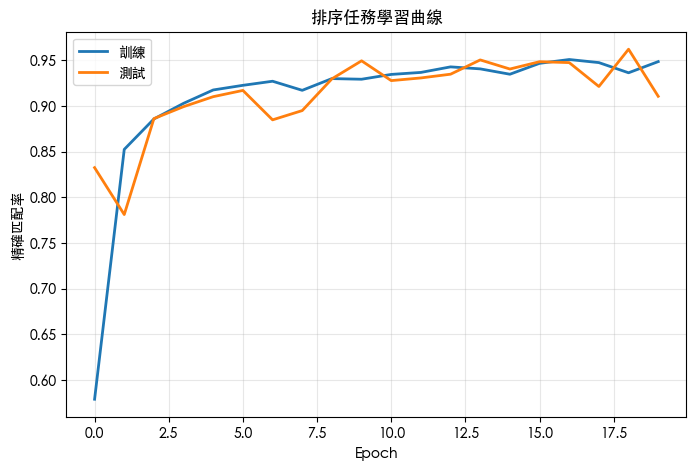

In [16]:
# 訓練排序模型
print("\n訓練排序任務的指標網路...")

sort_model = PointerNetwork(input_dim=1, hidden_dim=64, use_mask=True).to(device)
sort_optimizer = torch.optim.Adam(sort_model.parameters(), lr=1e-3)

sort_history = {'train_exact_acc': [], 'test_exact_acc': []}

for epoch in range(1, 21):
    tf_ratio = max(0.2, 1.0 - epoch / 20)
    
    # 訓練
    train_metrics = train_epoch(sort_model, sort_train_loader, sort_optimizer, device, tf_ratio)
    test_metrics = evaluate(sort_model, sort_test_loader, device)
    
    sort_history['train_exact_acc'].append(train_metrics['exact_acc'])
    sort_history['test_exact_acc'].append(test_metrics['exact_acc'])
    
    if epoch % 5 == 0:
        print(f"Epoch {epoch:2d} | Train Exact Acc: {train_metrics['exact_acc']:.4f} | "
              f"Test Exact Acc: {test_metrics['exact_acc']:.4f}")

# 繪製學習曲線
plt.figure(figsize=(8, 5))
plt.plot(sort_history['train_exact_acc'], label='訓練', linewidth=2)
plt.plot(sort_history['test_exact_acc'], label='測試', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('精確匹配率')
plt.title('排序任務學習曲線')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


排序預測視覺化:


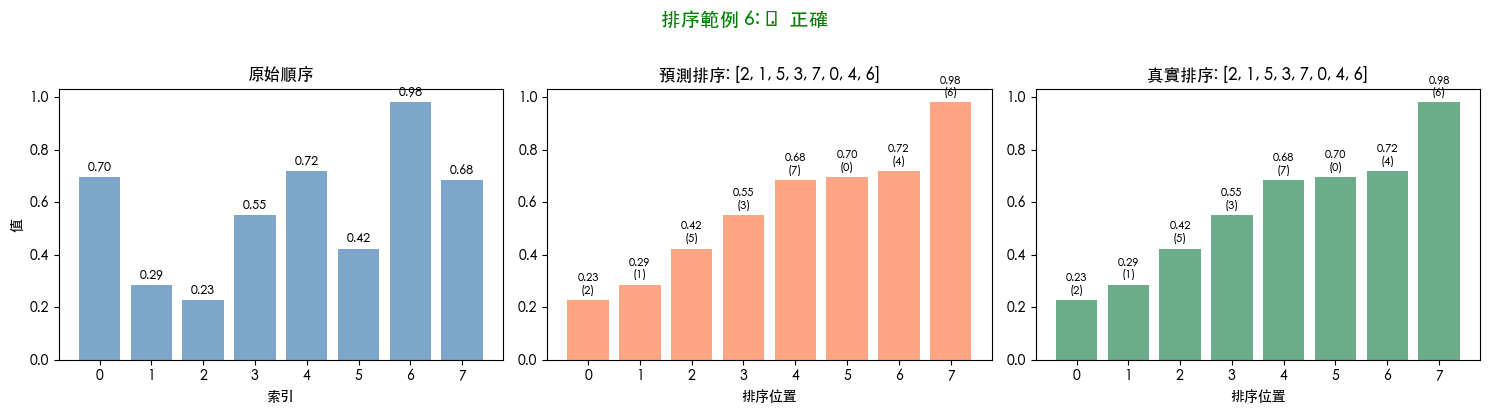

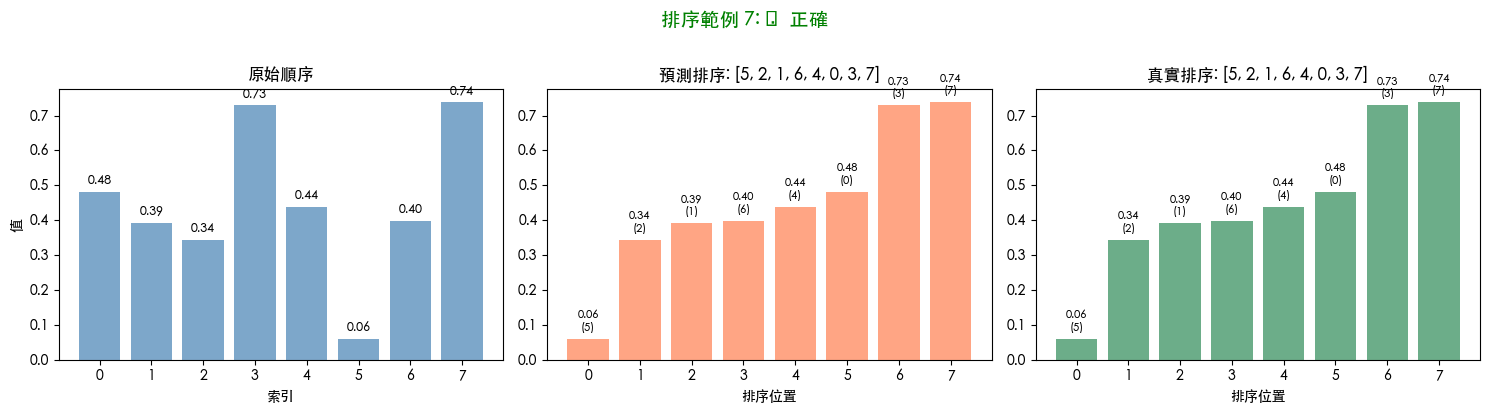

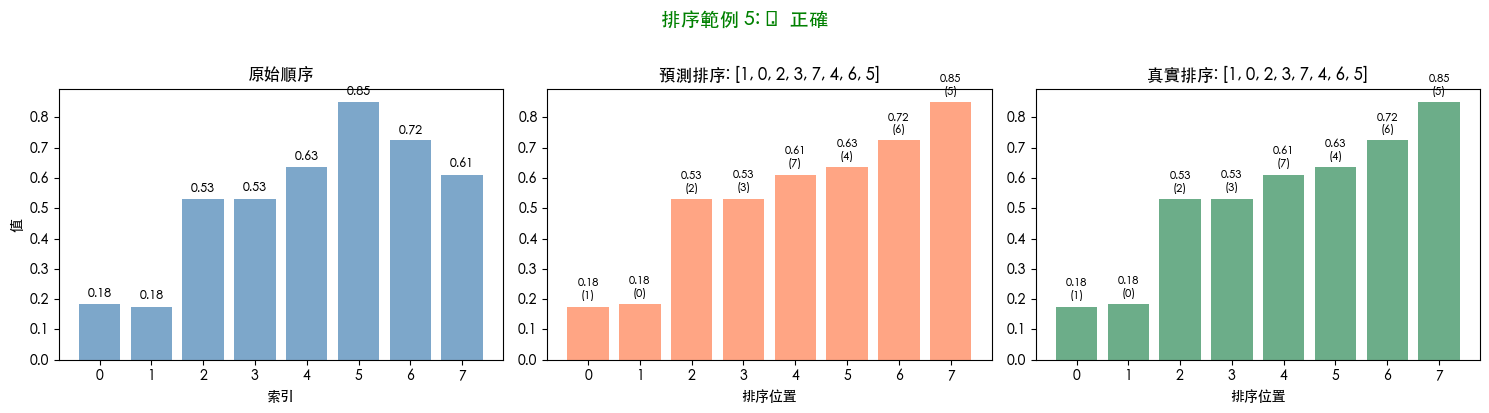

In [17]:
# 視覺化排序預測
def visualize_sorting_prediction(model, dataset, idx, device):
    model.eval()
    
    inputs, targets = dataset[idx]
    inputs_tensor = inputs.unsqueeze(0).to(device)
    
    with torch.no_grad():
        probs, indices = model(inputs_tensor)
    
    values = inputs.squeeze().numpy()
    predicted = indices[0].cpu().numpy()
    true_order = targets.numpy()
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    # 原始順序
    ax = axes[0]
    bars = ax.bar(range(len(values)), values, color='steelblue', alpha=0.7)
    for i, v in enumerate(values):
        ax.text(i, v + 0.02, f'{v:.2f}', ha='center', fontsize=9)
    ax.set_title('原始順序')
    ax.set_xlabel('索引')
    ax.set_ylabel('值')
    
    # 預測排序
    ax = axes[1]
    sorted_by_pred = values[predicted]
    bars = ax.bar(range(len(sorted_by_pred)), sorted_by_pred, color='coral', alpha=0.7)
    for i, (v, idx) in enumerate(zip(sorted_by_pred, predicted)):
        ax.text(i, v + 0.02, f'{v:.2f}\n({idx})', ha='center', fontsize=8)
    ax.set_title(f'預測排序: {predicted.tolist()}')
    ax.set_xlabel('排序位置')
    
    # 真實排序
    ax = axes[2]
    sorted_by_true = values[true_order]
    bars = ax.bar(range(len(sorted_by_true)), sorted_by_true, color='seagreen', alpha=0.7)
    for i, (v, idx) in enumerate(zip(sorted_by_true, true_order)):
        ax.text(i, v + 0.02, f'{v:.2f}\n({idx})', ha='center', fontsize=8)
    ax.set_title(f'真實排序: {true_order.tolist()}')
    ax.set_xlabel('排序位置')
    
    is_correct = np.array_equal(predicted, true_order)
    plt.suptitle(f'排序範例 {idx}: {"✓ 正確" if is_correct else "✗ 錯誤"}',
                fontsize=14, y=1.02, color='green' if is_correct else 'red')
    plt.tight_layout()
    plt.show()


# 視覺化幾個排序範例
print("\n排序預測視覺化:")
for i in range(3):
    visualize_sorting_prediction(sort_model, sort_test, i, device)

## 10. 關鍵要點總結

### 指標網路的創新

1. **輸出詞彙表 = 輸入序列**
   - 不需要固定的輸出詞彙表
   - 可以處理任意長度的輸入

2. **注意力作為輸出**
   - 傳統注意力計算上下文向量
   - 指標網路直接使用注意力分布作為輸出機率

3. **組合最佳化的神經網路方法**
   - 凸包、TSP、排序等問題
   - 可以用監督學習或強化學習訓練

### 架構組件

$$u_i^t = v^T \tanh(W_1 h_i + W_2 s_t)$$
$$p(C_t = i) = \frac{\exp(u_i^t)}{\sum_j \exp(u_j^t)}$$

### 後續影響

- **Transformer 自注意力**：注意力機制的進一步發展
- **複製機制**：在文本生成中從輸入複製詞彙
- **神經組合最佳化**：開創了一個新的研究方向

## 論文連結

**Pointer Networks**

https://arxiv.org/abs/1506.03134

![論文 QR Code](paper_qrcode.png)